# **Delivery Market Modelling**

_This data project has been used as a take-home assignment in the recruitment process for the data science positions at Delhivery._

Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.

Assignment
----------

The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency, and profitability of their business versus their competitors.

The company wants to understand and process the data coming out of data engineering pipelines:

*   Clean, sanitize and manipulate data to get useful features out of raw fields;
*   Make sense of the raw data and help the data science team to build forecasting models on it.

Data Description
----------------

`delhivery_data.csv` contains records of deliveries prepared by the data engineering department for modeling and has the following columns:

*   `data` – tells whether the data is testing or training data
*   `trip_creation_time` – Timestamp of trip creation
*   `route_schedule_uuid` – unique Id for a particular route schedule
*   `route_type` – transportation type:
    *   `FTL` – Full Truck Load: FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way
    *   `Carting` – handling system consisting of small vehicles (carts)
*   `trip_uuid` - unique ID given to a particular trip (A trip may include different source and destination centers)
*   `source_center` – ID of a trip origin point
*   `source_name` – the name of a trip origin point
*   `destination_center` – destination ID
*   `destination_name` – destination Name
*   `od_start_time` – trip start time
*   `od_end_time` – trip end time
*   `start_scan_to_end_scan` – time taken to deliver from source to destination
*   `is_cutoff` – unknown field
*   `cutoff_factor` – unknown field
*   `cutoff_timestamp` – unknown field
*   `actual_distance_to_destination` – the distance in kilometers between the source and destination
*   `actual_time` – actual time taken to complete the delivery (cumulative)
*   `osrm_time` – an open-source routing engine time calculator which computes the shortest path between points in a given map (given usual traffic) and gives the time estimate (cumulative)
*   `osrm_distance` – an open-source routing engine that computes the distance of the shortest path between points in a given map (cumulative)
*   `factor` – unknown field
*   `segment_actual_time` – time taken by a segment of the package delivery
*   `segment_osrm_time` – the OSRM segment time
*   `segment_osrm_distance` – the OSRM distance for a segment
*   `segment_factor` – unknown field

Practicalities
--------------

Analyze the provided data and provide insights to the best of your abilities. Use statistical tests to support your claims. Include the relevant tables/graphs/visualization to explain what you have learned about the market. Make sure that the solution reflects your entire thought process including the preparation of data - it is more important how the code is structured rather than just the final result or plot.

## Import Library & Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv('datasets/delivery_data.csv')
df.head(10)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
5,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 06:15:58,10.403038,15.0,11.0,12.1171,1.363636,15.0,11.0,12.1171,1.363636
6,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:47:29,18.045481,44.0,17.0,21.2890,2.588235,28.0,6.0,9.1719,4.666667
7,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:25:58,28.061896,65.0,29.0,35.8252,2.241379,21.0,11.0,14.5362,1.909091
8,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 05:15:56,38.939167,76.0,39.0,47.1900,1.948718,10.0,10.0,11.3648,1.000000
9,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),IND388320AAA,Anand_Vaghasi_IP (Gujarat),2018-09-20 04:47:45.236797,...,2018-09-20 04:49:20,43.595802,102.0,45.0,53.2334,2.266667,26.0,6.0,6.0434,4.333333


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [3]:
df.shape

(144867, 24)

### Check for Missing Data

In [4]:
def missing_data(input_data):
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum() / input_data.isnull().count() * 100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns:
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table)) 

missing_data(df)

,Total,Percent,Types
data,0,0.000000,object
trip_creation_time,0,0.000000,object
route_schedule_uuid,0,0.000000,object
route_type,0,0.000000,object
trip_uuid,0,0.000000,object
source_center,0,0.000000,object
source_name,293,0.202254,object
destination_center,0,0.000000,object
destination_name,261,0.180165,object
od_start_time,0,0.000000,object


## Data Clearning

In [5]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

df['source_name'] = df['source_name'].fillna('Unknown')
df['destination_name'] = df['destination_name'].fillna('Unknown')

df = df.drop_duplicates()

## Feature Engineering

In [6]:
df['od_trip_duration'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 3600
df['time_diff'] = df['actual_time'] - df['osrm_time']
df['efficiency'] = df['actual_distance_to_destination'] / df['osrm_distance']

## Statistical Analysis

### Exploring Relationships Between Variables (Correlation Analysis)

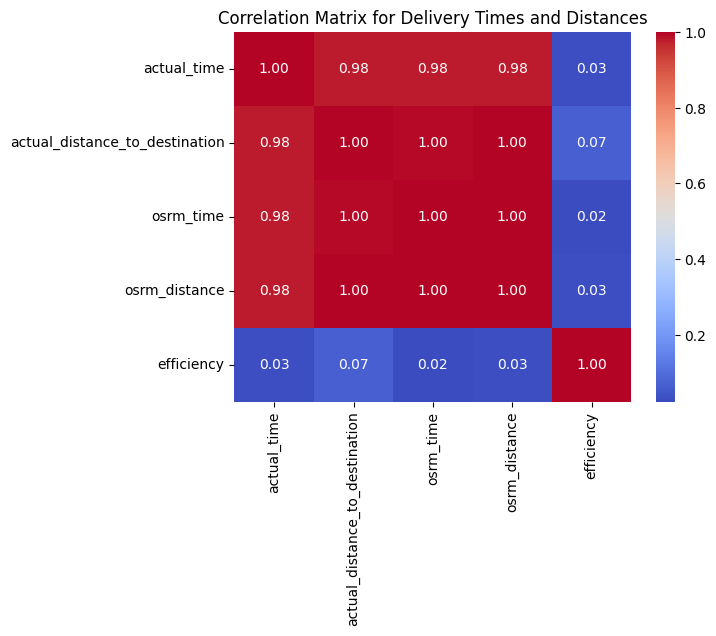

In [7]:
# Correlation between numerical variables
corr_matrix = df[['actual_time', 'actual_distance_to_destination', 'osrm_time', 'osrm_distance', 'efficiency']].corr()

# Visualize the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Delivery Times and Distances')
plt.show()


### Comparing Delivery Time by Transportation Type

In [8]:
ftl_times = df[df['route_type'] == 'FTL']['actual_time']
carting_times = df[df['route_type'] == 'Carting']['actual_time']

# Perform t-test to check if there's a significant difference
t_stat, p_value = stats.ttest_ind(ftl_times, carting_times)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 161.1774496644187, P-value: 0.0


The p-value is below a threshold (e.g., 0.05), we can conclude that the delivery times for the two route types differ significantly.

### Time Series Analysis for Delivery Time Trends

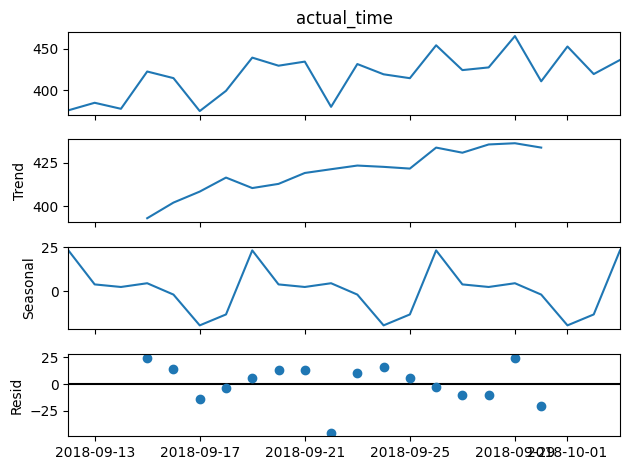

In [9]:
# Set the index to trip_creation_time and resample by day
df.set_index('trip_creation_time', inplace=True)
df_resampled = df['actual_time'].resample('D').mean()

# Decompose the time series
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_resampled, model='additive')
decomposition.plot()
plt.show()


### Kruskal-Wallis Test for Non-Normal Distributions

In [10]:
kruskal_stat, p_value = stats.kruskal(
    df[df['route_type'] == 'FTL']['actual_time'],
    df[df['route_type'] == 'Carting']['actual_time']
)
print(f"Kruskal-Wallis statistic: {kruskal_stat}, p-value: {p_value}")

Kruskal-Wallis statistic: 47963.98761823553, p-value: 0.0


### Delivery Efficiency by Source-Destination Pair

In [11]:
df['efficiency'] = df['actual_distance_to_destination'] / df['osrm_distance']

efficiency_by_route = df.groupby(['source_name', 'destination_name'])['efficiency'].mean()
poor_efficiency_routes = efficiency_by_route[efficiency_by_route > 1]

poor_efficiency_routes

Series([], Name: efficiency, dtype: float64)

### Boxplots for Delivery Time Outliers

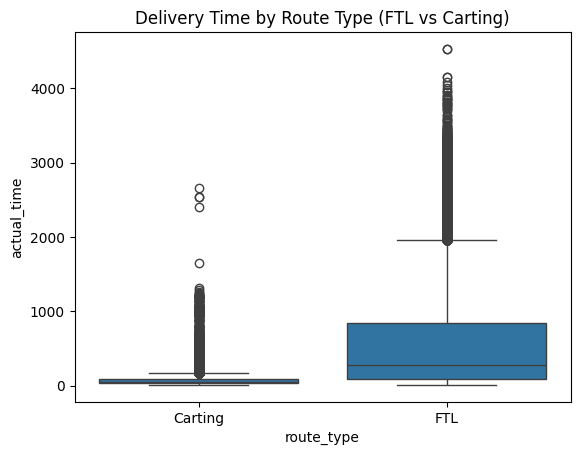

In [12]:
sns.boxplot(x='route_type', y='actual_time', data=df)
plt.title('Delivery Time by Route Type (FTL vs Carting)')
plt.show()

### Chi-Square Test for Categorical Data

In [13]:
contingency_table = pd.crosstab(df['route_type'], df['is_cutoff'])
chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2 Stat: {chi2_stat}, p-value: {p_val}")

Chi2 Stat: 3754.7132188588835, p-value: 0.0


The p-value is less than 0.05, you can reject the null hypothesis and conclude that there is an association between route_type and whether a cutoff occurred.

## Data Visualization

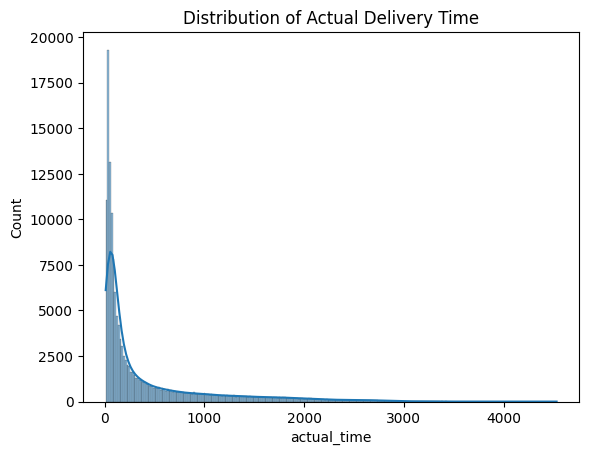

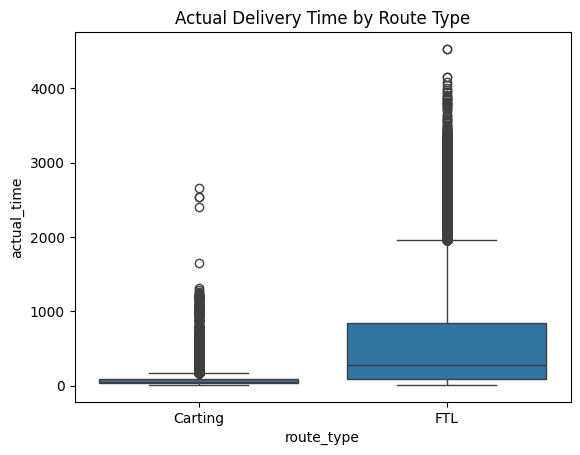

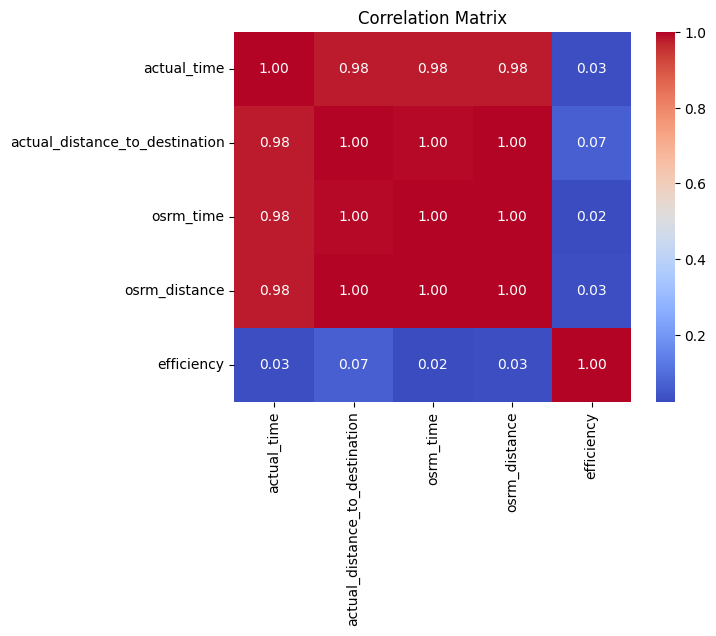

In [14]:
sns.histplot(df['actual_time'], kde=True)
plt.title('Distribution of Actual Delivery Time')
plt.show()

sns.boxplot(x='route_type', y='actual_time', data=df)
plt.title('Actual Delivery Time by Route Type')
plt.show()

corr_matrix = df[['actual_time', 'actual_distance_to_destination', 'osrm_time', 'osrm_distance', 'efficiency']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Modeling Support for Forecasting